This script takes all of the results.csv files performed created in data_model_fit.ipynb, appends all of them into one data file called mscore.csv. It performs a filtering algorithm to identify from mscore.csv by permutation the all possible pairs that fit certain criteria (valid_transitions.csv). From those criteria the change in certain key variables is computed and plotted (vt_list.csv).

Provided are the output files mscore.csv, valid_transitions.csv, vt_list.csv and any figures generated fromt these files. Contact corresponding author for simulations used in generating this output. 

In [1]:
# =======================
# Standard Library Imports
# =======================
import os

# =======================
# Data Handling/Math Operations
# =======================
import pandas as pd
import numpy as np

# =======================
# Plotting and Visualization
# =======================
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob


# Setup


In [2]:
# # code to take all results from ensemble_output and append them into one datafile, 
output_path = "../results/mscore.csv"

# globular = r"/path_to_simulations/*/results.csv" # local directory

# if os.path.exists(output_path): 
#     print(f"{output_path} already exists. Skipping writing.") # control to prevent overwriting
# else:
#     write_header = True
#     for name in glob.glob(globular):
#         file = pd.read_csv(name)
#         file.to_csv(output_path, mode='a', header=write_header, index=False)
#         write_header = False  # write header only once
#     print(f"Files merged and saved to {output_path}")

Files merged and saved to C:/Users/prowa/cGENIE_processing/Results/Results_Jan/mscore.csv


In [3]:
# read in mscore data, make sure all values are uniform in format
df = pd.read_csv(output_path)

# ensure uniformity, convert strings to numeric and convert all numers to floats

df['pCO2'] = df['pCO2'].map(
    lambda x: float(str(x).replace('x', '').strip()) if isinstance(x, str) else x)

df['efolding (m)'] = df['efolding (m)'].map(
    lambda x: float(str(x).replace('x', '').strip()) if isinstance(x, str) else x)

#reject any remin depths that say TD 

df = df[df['efolding (m)'] != "TD"]

# from mscore.csv get the unique values for state, remineralization depth and pCO2, 

print(df.head())

print(df['State'].unique())
print(df['pCO2'].unique())
print(df['efolding (m)'].unique())

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/prowa/cGENIE_processing/Results/Results_Jan/mscore.csv'

In [ ]:
#make separate copies of the kellwasser nd background entries
background = df[df['State'] == 'Background'].copy()
event = df[df['State'] == 'Kellwasser'].copy()

# Perform a Cartesian product to generate all possible transitions
background['key'] = 1
event['key'] = 1
transitions = background.merge(event, on='key', suffixes=('_bg', '_ev')).drop(columns=['key']) # add a suffic bg or ev to distinguish


From the prepared dataframe, apply the conditions for a valid transiton and save as a new dataframe called valid_transitions and save as csv

In [ ]:

#add remove conditions as necessary
valid_transitions = transitions[
    (transitions['mscore_bg'] > 0.35) &                                                     # background M-score at least (>) 0.3
    (transitions['mscore_ev'] > 0.35) &                                                     # event M-score > 0.3

    (abs(transitions['pO2_ev'] - transitions['pO2_bg']) / transitions['pO2_bg'] <= 0.2) &  # pO2 changes no more than (≤) 20%
    #(abs(transitions['PO4_ev'] - transitions['PO4_bg']) / transitions['PO4_bg'] <= 0.5) &  # PO4 changes no more than (≤) 50%

    ((transitions['benthic_anoxia_ev'] - transitions['benthic_anoxia_bg']) >= 5) &         # anoxia increases ≥ 5%
    ((transitions['benthic_anoxia_ev'] - transitions['benthic_anoxia_bg']) <= 15) &         # anoxia increases ≤ 15%

    ((transitions['globe_avg_temp (C)_bg'] - transitions['globe_avg_temp (C)_ev'])>=3)              # temperature cooling greater than 3deg
    # ((transitions['globe_avg_temp (C)_bg'] - transitions['globe_avg_temp (C)_ev']) <= 6)           # temperature cooling less than 6deg
]


print(f"Valid Transitions Found: {len(valid_transitions)}")

# save to csv, use os.pathexist to not overwrite
output_path = "../results/valid_transitions.csv"

if not os.path.exists(output_path): #need if not because testing if conditions == True/False or else if wont print else statement
    valid_transitions.to_csv(output_path, mode='w', header=True, index=False)
    valid_transitions.head(5)
else:
    print('already exists')

# Calculate

From valid_transitions calculate the change between key variables (e.g., dissolve O2) 

In [ ]:
#read in transitions to dataframe
valid_transitions = pd.read_csv("../results/valid_transitions.csv")
valid_transitions.head(5)

In [ ]:
#if x (as in times a number thus making it a string) exists, drop it
valid_transitions = valid_transitions.applymap(lambda x: x.replace('x', '') if isinstance(x, str) else x)

#convert numbers to numeric, don't coerce strings to nan
valid_transitions = valid_transitions.apply(pd.to_numeric, errors='ignore')

valid_transitions.head(5)

#add the columns for the observed change in pO2, PO4, temp and efolding
valid_transitions['PO4_change'] = valid_transitions['PO4_ev'] - valid_transitions['PO4_bg'] #positive is increase in PO4
valid_transitions['pO2_change'] = valid_transitions['pO2_ev'] - valid_transitions['pO2_bg'] # positive is increase in atmospheric oxygen
valid_transitions['temp_change'] = valid_transitions['globe_avg_temp (C)_bg'] - valid_transitions['globe_avg_temp (C)_ev'] # positive is cooling
valid_transitions['benthic_anoxia_change'] = valid_transitions['benthic_anoxia_ev'] - valid_transitions['benthic_anoxia_bg'] # pos is increase in benthic anoxia
valid_transitions['efolding_change'] = valid_transitions['efolding (m)_ev'] - valid_transitions['efolding (m)_bg'] #negative is shallowing
valid_transitions['dissolved_O2_change'] = valid_transitions['dissolved_O2_sur (molkg-1x1E6)_ev'] - valid_transitions['dissolved_O2_sur (molkg-1x1E6)_bg'] #negative is more exygen depleted



add a counter for valid_transitions based on frequency of occurance of unique entries. For example, in the above df, the first 5 entries are the same background state that was selected to match up with 5 different kellwasser states. 

In [ ]:
# Use unique values (m-score and benthic_anoxia are most characteristic). 

#group_bg and _ev cols
bg_cols = [col for col in valid_transitions.columns if col.endswith('_bg')]
ev_cols = [col for col in valid_transitions.columns if col.endswith('_ev')]

#df.groupby().ngroup() is used to number each group created by a groupby operation
valid_transitions['index'] = range(1, len(valid_transitions) + 1)


valid_transitions['group_id_bg'] = valid_transitions.groupby(bg_cols).ngroup()

valid_transitions['group_count_bg'] = valid_transitions.groupby(bg_cols)[bg_cols[0]].transform('count')

valid_transitions['group_id_ev'] = valid_transitions.groupby(ev_cols).ngroup()

valid_transitions['group_count_ev'] = valid_transitions.groupby(ev_cols)[ev_cols[0]].transform('count')

#assign a letter to each simulation
number_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D',4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J', 10: 'K', 11: 'L',
                    12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 
                    23: 'X', 24: 'Y', 25:'Z', 26:'α', 27:'β', 28: 'γ'}

letter_to_lower={}

for key in number_to_letter:
    letter_to_lower[key] = str(number_to_letter[key].lower())
    
# Apply the mapping to create a new column
valid_transitions['ID_bk'] = valid_transitions['group_id_bg'].map(number_to_letter)
valid_transitions['ID_ev'] = valid_transitions['group_id_ev'].map(letter_to_lower)

# add to original dataframe
valid_transitions.head(5)

# reorder based on sum of group_count_bg and group_count_ev: this represents a scenario that balances frequency of backgroundandkellwasser state beingselected

valid_transitions['harmonic_mean'] = 2*(valid_transitions['group_count_ev'] * valid_transitions['group_count_bg'])/(valid_transitions['group_count_ev'] + valid_transitions['group_count_bg'])*10

vt_list = valid_transitions.sort_values(by = "harmonic_mean", ascending = False)


valid_transitions['weighted_harmonic_mean'] = 2*(valid_transitions['mscore_bg']*valid_transitions['group_count_ev'] * valid_transitions['mscore_ev']*valid_transitions['group_count_bg'])/(valid_transitions['group_count_ev'] + valid_transitions['group_count_bg'])*10

vt_list = valid_transitions.sort_values(by = "weighted_harmonic_mean", ascending = False)


Save output into new dataframe and csv file called vt_list that contains everying in valid_transitons plus all the calculated values

In [ ]:
output_path = "../results/vt_list.csv"

if not os.path.exists(output_path): #need if not because testing if conditions == True/False or else if wont print else statement
    vt_list.to_csv(output_path, mode='w', header=True, index=False)
    vt_list.head(5)
else:
    print('already exists')


## Plot transitions

In [5]:
#Read in vt_list

vt_list = pd.read_csv(output_path)

In [6]:
# Define axes, change relative to background state 
vt_list['pO2_change'] = (vt_list['pO2_ev'] - vt_list['pO2_bg']) / vt_list['pO2_bg']
vt_list['PO4_ratio'] = (vt_list['PO4_ev'] - vt_list['PO4_bg']) / vt_list['PO4_bg']
vt_list['depth_change'] = vt_list['efolding (m)_ev'] - vt_list['efolding (m)_bg']

# # example: row 3 must be <= threshold
# abs_pO2 = vt_list['pO2_change'].abs()
# min_abs = abs_pO2.min()

# mask = abs_pO2 == min_abs

# idx = (
#     -vt_list.loc[mask, 'PO4_ratio']
#   - vt_list.loc[mask, 'temp_change']
# ).idxmax()

# print(idx)

# vt_list.loc[idx]

Plot $\Delta \mathrm{PO}_{4}$ vs $\Delta \mathrm{pO}_{2}$ for all transitions with symbols representing remineralization depth change

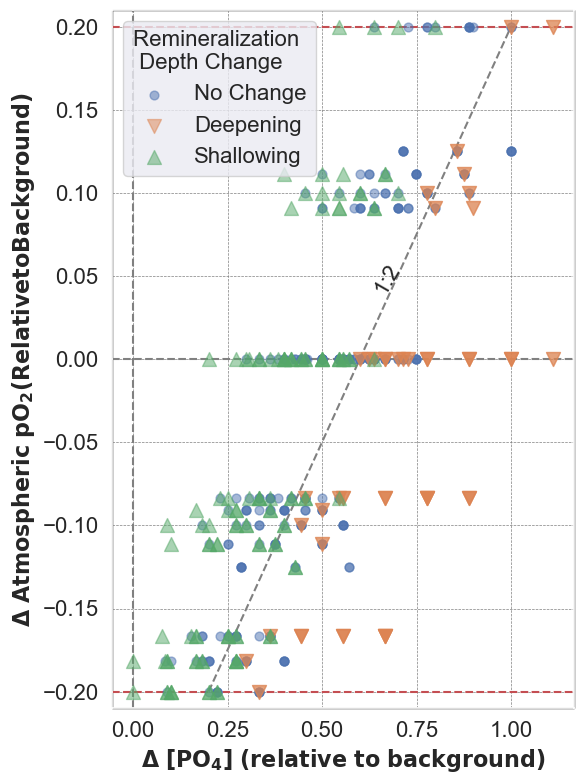

In [11]:
###### from matplotlib.patches import Circle

# create custom marker style based on depth change value
def symbol_type(change):
    if change > 0:
        return 'v'  # deepening
    elif change == 0:
        return 'o'  # no change
    elif change < 0:
        return '^'  # shallowing
    else:
        return 'x'

vt_list['marker'] = vt_list['depth_change'].apply(symbol_type)

marker_labels = {
    '^': 'Shallowing',
    'o': 'No Change',
    'v': 'Deepening',
    'x': 'Unknown'
}

######
# set up plot

sns.set()
fig, ax = plt.subplots(figsize=(6, 8))

# Plot each marker type
for marker in vt_list['marker'].unique():
    subset = vt_list[vt_list['marker'] == marker]
    
    # Size by symbol type
    size = 100 if marker in ['^', 'v'] else 40 # this is so overlapping symbols are not the same size

    scatter = ax.scatter(
        subset['PO4_ratio'],
        subset['pO2_change'],
        marker=marker,
        alpha=0.5,
        s=size,
        label=marker_labels.get(marker, marker),
        zorder = 3
    )

    # # Label each point, if there are not too many...
    # for _, row in subset.iterrows():
    #     ax.text(
    #         row['PO4_ratio'] + 0.005,   # slight x-offset
    #         row['pO2_change'] + 0.005,  # slight y-offset
    #         str(row['index']),           # use the index column from vt_list
    #         fontsize=12,
    #         ha='left',
    #         va='bottom',
    #         color='black'
    # )

# Axes, grid, lines
ax.grid(color='grey', linestyle='--', linewidth=0.5)
ax.minorticks_on()

# draw the lines (no labels)
ax.axhline(y=0.2, color='r', linestyle='--')
ax.axhline(y=-0.2, color='r', linestyle='--')
ax.axvline(x=0, color='grey', linestyle='--', zorder=1)
ax.axhline(y=0, color='grey', linestyle='--', zorder=2)

plt.ylim(-0.21, 0.21)
#plt.xlim(-0.55, 0.55)

# Labels
ax.set_xlabel(
    r"$\mathbf{\Delta\ [PO_{4}]\ (relative\ to\ background)}$",
    fontsize=16
)

ax.set_ylabel(r"$\mathbf{\Delta\ Atmospheric\ pO_{2}(Relative to Background)} $ ", fontsize = 16)
ax.tick_params(axis='both', which='major', labelsize=16) 


# Place custom text on graphing window
# ax.text(0.52, 0.2, "+20% pO$_2$", color="r", va="center", ha="left")
# ax.text(0.52, -0.2, "–20% pO$_2$", color="r", va="center", ha="left")

# Legend only for other plotted data
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Remineralization \n Depth Change", loc="upper left", title_fontsize = 16, fontsize = 16)

#make pretty
fig.set_facecolor('white') 
ax.set_facecolor('white')
ax.patch.set_edgecolor('black') # Set the border color
ax.patch.set_linewidth(1) 


ax.plot([0.2, 1.0], [-0.2, 0.2], linestyle = 'dashed', color = "grey")
ax.text(0.63, 0.04, "1:2", fontsize = 16, rotation = 60)
            
# plt.title("Valid Transitions", fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.tight_layout()
plt.savefig("Transitions_pO2vsPO4_anytempchange.png", dpi = 300, bbox_inches='tight', pad_inches=0.05)     # trims extra whitespace around figure
    
plt.show()


# Stacked Heatmaps

In [25]:
mscores = pd.read_csv("../results/mscore.csv")

pco2 = 10.0
# state = "Background"
state = "Kellwasser"

# subset_df = df.loc[df['column_name'] == 'specific_value']
sub = mscores.loc[mscores['pCO2'] == pco2]
subset=sub.loc[sub['State'] == state]
subset.head()

# subset['mscore'] = subset['mscore'].round(2)
values = subset[['pO2',  'PO4','mscore','efolding (m)', 'State', 'pCO2']].dropna()
values.head()
# condition = values['PO4'] > 1.9
# filtered_df = values[condition]

# with pd.option_context('display.max_rows', None):
#     print(filtered_df)

,pO2,PO4,mscore,efolding (m),State,pCO2
25,1.2,0.5,0.016517,0.5,Kellwasser,10.0
26,1.1,0.5,0.016522,0.5,Kellwasser,10.0
27,1.0,0.5,0.016529,0.5,Kellwasser,10.0
28,0.9,0.5,0.016537,0.5,Kellwasser,10.0
29,0.8,0.5,0.016548,0.5,Kellwasser,10.0


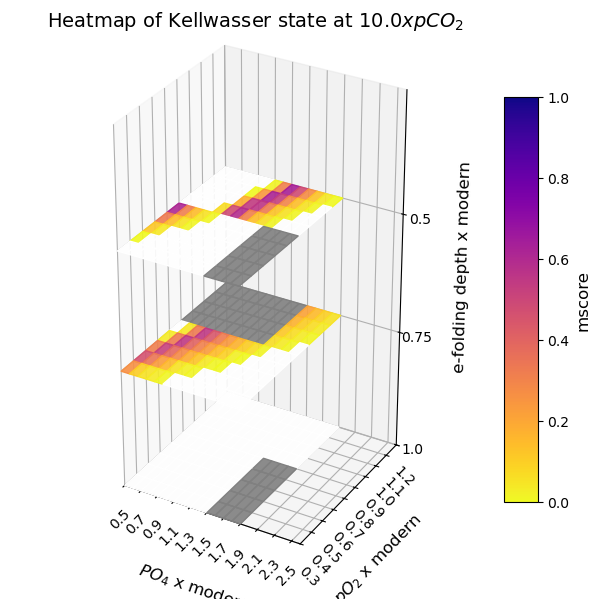

In [35]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm

cmap = plt.cm.plasma_r
cmap.set_bad('grey')
cmap.set_under("white")

third_var = 'efolding (m)'
unique_values = sorted(values[third_var].unique())
fig = plt.figure(figsize=(7, 10),facecolor='white')
ax = fig.add_subplot(111, projection='3d',facecolor='white')

for idx, value in enumerate(unique_values):
    subset = values[values[third_var] == value].copy()
    subset['mscore'] = subset['mscore'].round(2)
    values_subset = subset[['pO2', 'PO4', 'mscore']].dropna()
    
    # Check for duplicates in the pO2/PO4 combination
    duplicates = values_subset[values_subset.duplicated(subset=['pO2', 'PO4'], keep=False)]
    # print(f"Duplicates for {third_var}={value}:")
    # print(duplicates)
    
    # Use pivot_table with aggregation function to handle duplicates
    pivot_subset = values_subset.pivot_table(index='pO2', columns='PO4', values='mscore', aggfunc='mean')
    
    # Get X, Y coordinates
    X, Y = np.meshgrid(pivot_subset.columns, pivot_subset.index)
    Z = np.ones_like(X) * idx  # Stack at different heights
    
    # Normalize mscore values for coloring (0 to 1)
    normalized_values = (pivot_subset.values - 0.05) / (1 - 0.05)
    
    # Plot surface with colors based on mscore
    surf = ax.plot_surface(X, Y, Z, facecolors=cm.plasma_r(normalized_values),
                          alpha=0.9, antialiased=True, shade=False)

############ Adjust axes ticks and labels
z_spacing = -1 
ax.set_zlim(0.2, z_spacing)
ax.set_box_aspect((1, 1, 2))
ax.set_xlabel(r'$PO_{4}$ x modern', labelpad = 10, fontsize=12, ha ='left')
ax.set_ylabel(r'$pO_{2}$ x modern', fontsize=12, labelpad = 10)
ax.set_zlabel('e-folding depth x modern', fontsize=12, labelpad = 20)
ax.set_xlim(0.5,2.6)
xticks = np.arange(0.5, 2.6, 0.2)   # every other major tick
ax.set_xticks(xticks)

ax.set_ylim(0.3, 1.2)
yticks = np.arange(0.3, 1.21, 0.3)
# ax.set_yticklabels(yticks)
ax.tick_params(axis='x', labelrotation=45, pad = .5)
ax.tick_params(axis='y', labelrotation=-45, pad=1)

ax.set_zticks(range(len(unique_values)))
ax.set_zticklabels([f'{v}' for v in unique_values])
title = "Heatmap of " + state + " state at "+ str(pco2) + r"$xpCO_{2}$" 
ax.set_title(title, fontsize=14, pad=20)

#################### Add colorbar
m = cm.ScalarMappable(cmap=cm.plasma_r)
m.set_array([0, 1])
cbar = plt.colorbar(
    m,
    ax=ax,
    shrink=0.45,
    aspect=12,
    pad=0.005
)
cbar.set_label('mscore', fontsize=12)

####################### Save
filename = "../figures/heatmap" +"_"+str(pco2) + "xpco2" +"_"+state+".png"
fig.subplots_adjust(
    left=0.05,
    right=0.88,
    bottom=0.02,
    top=0.92
)

# plt.savefig(filename, dpi=300, bbox_inches="tight")

plt.show()

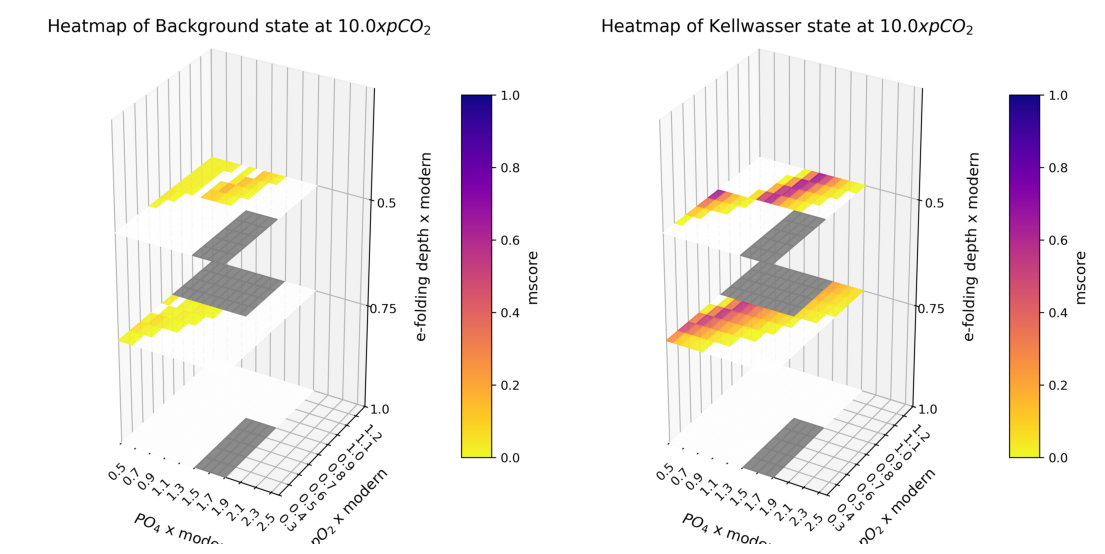

In [39]:
import matplotlib.image as mpimg
plots = ["C:/Users/prowa/cGENIE_processing/Figures/heatmaps/heatmap_10.0xpco2_Background.png",
        "C:/Users/prowa/cGENIE_processing/Figures/heatmaps/heatmap_10.0xpco2_Kellwasser.png"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))

img_data = mpimg.imread(plots[0])
ax1.imshow(img_data)
ax1.axis("off")

img_data = mpimg.imread(plots[1])
ax2.imshow(img_data)
ax2.axis("off")

fig.subplots_adjust(wspace=0.02)  # smaller = closer
filename = "Figures/heatmaps/heatmap" +"_"+str(pco2) + "xpco2"+".png"

plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

